Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.93      0.91      4503
         1.0       0.75      0.65      0.69      1530

    accuracy                           0.86      6033
   macro avg       0.82      0.79      0.80      6033
weighted avg       0.85      0.86      0.85      6033

Accuracy: 0.8552958727001492

 K-Means Cluster Counts:
cluster
0    17602
1    12560
Name: count, dtype: int64


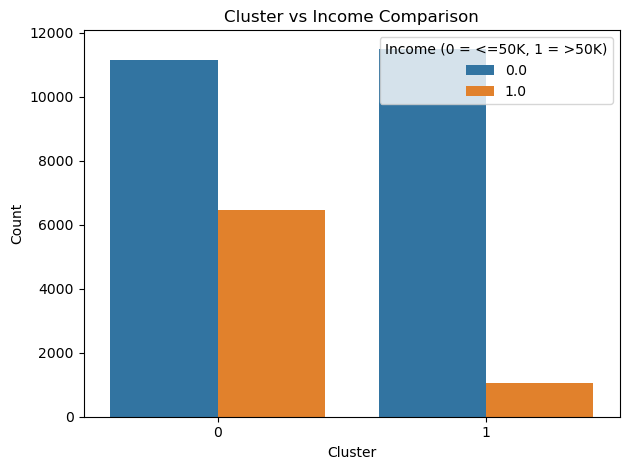

In [ ]:
# Import Libraries
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load Dataset from UCI 
census_income = fetch_ucirepo(id=20)
X_raw = census_income.data.features
y_raw = census_income.data.targets

# Combine features and target for processing
df = X_raw.copy()
df['income'] = y_raw

# Step 2: Clean Data 
# Replace '?' with NaN and drop rows with missing values
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

# Step 3: Encode Categorical Variables
# Map income values to binary labels
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
df = df[df['income'].notna()]  # Remove any rows where mapping failed (NaN)

# Encode all other categorical features
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Step 4: Prepare Data for Supervised Learning
X = df.drop('income', axis=1)
y = df['income']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Step 6: Evaluate Supervised Model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Step 7: Unsupervised Learning (K-Means)
# Normalize data for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means with 2 clusters (based on income binary nature)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Step 8: Analyze K-Means Clustering
print("\n K-Means Cluster Counts:")
print(df['cluster'].value_counts())

# Step 9: Visualize Clustering vs. Income
sns.countplot(x='cluster', hue='income', data=df)
plt.title('Cluster vs Income Comparison')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Income (0 = <=50K, 1 = >50K)')
plt.tight_layout()
plt.show()

